In [74]:
from matplotlib import pyplot as plt

import pyreadr
import numpy as np
import pandas as pd
import copy
from scipy.optimize import fmin_slsqp
from sklearn.metrics import mean_squared_error

from matrix import Matrix
from synthetic_control import SyntheticControl
import syslibutils as utils

In [75]:
START_TIME = 1970
INTERVENTION_TIME = 1989
STOP_TIME = 2001

T0 = INTERVENTION_TIME - START_TIME
T = STOP_TIME - START_TIME

print("T0  : ", T0)
print("T   : ", T)

T0  :  19
T   :  31


In [76]:
df_outcome_raw = pd.read_csv('../data/prop99.csv')
df_outcome_raw = df_outcome_raw[df_outcome_raw['SubMeasureDesc'] == 'Cigarette Consumption (Pack Sales Per Capita)']
df_outcome = pd.DataFrame(df_outcome_raw.pivot_table(values='Data_Value', index='LocationDesc', columns=['Year']).to_records())

df_outcome.index = df_outcome['LocationDesc']
df_outcome = df_outcome.drop(columns=['LocationDesc'])
df_outcome = df_outcome.iloc[:, :T+1]
df_outcome.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
LocationDesc,,,,,,,,,,,,,,,,,,,,,
Alabama,89.8,95.4,101.1,102.9,108.2,111.7,116.2,117.1,123.0,121.4,...,109.1,108.5,107.1,102.6,101.4,104.9,106.2,100.7,96.2,90.5
Alaska,121.3,123.0,130.0,125.8,130.4,150.4,164.8,159.3,143.6,138.1,...,98.5,95.2,94.1,89.5,89.9,81.7,78.6,70.5,66.0,65.2
Arizona,115.2,109.6,125.0,128.3,133.1,121.8,122.3,121.7,124.7,124.6,...,79.0,80.3,79.0,77.3,71.4,64.6,66.0,61.7,58.5,54.1
Arkansas,100.3,104.1,103.9,108.0,109.7,114.8,119.1,122.6,127.3,126.5,...,126.0,113.8,108.8,113.0,110.7,108.7,109.5,104.8,99.4,101.7
California,123.0,121.0,123.5,124.4,126.7,127.1,128.0,126.4,126.1,121.9,...,67.5,63.4,58.6,56.4,54.5,53.8,52.3,47.2,41.6,38.0


In [77]:
M = Matrix(df_outcome.T, T0 = T0, target_name="California")

print(M.pre_donor.shape)
print(M.post_donor.shape)

(19, 50)
(13, 50)


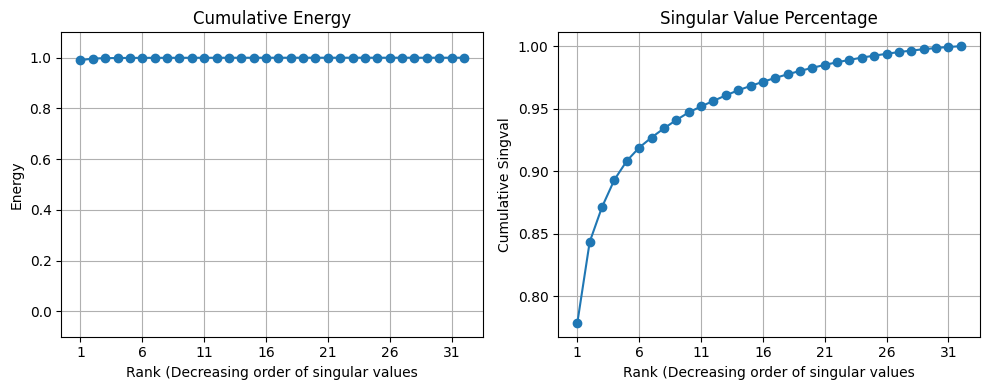

array([4.79903141e+03, 3.98716475e+02, 1.72476606e+02, 1.34085391e+02,
       9.26104092e+01, 6.53468668e+01, 4.97746200e+01, 4.50204323e+01,
       4.10441539e+01, 3.74996524e+01, 2.94692958e+01, 2.74089699e+01,
       2.68942312e+01, 2.53510505e+01, 2.11635246e+01, 2.04367881e+01,
       1.93198887e+01, 1.77811236e+01, 1.65581731e+01, 1.54436224e+01,
       1.42188135e+01, 1.28924798e+01, 1.19433039e+01, 1.11222015e+01,
       9.69455255e+00, 8.94119068e+00, 8.79921310e+00, 7.06989964e+00,
       6.79775274e+00, 6.03475441e+00, 4.99400651e+00, 3.95518337e+00])

In [78]:
utils.singval_test(df_outcome)

(51, 32)


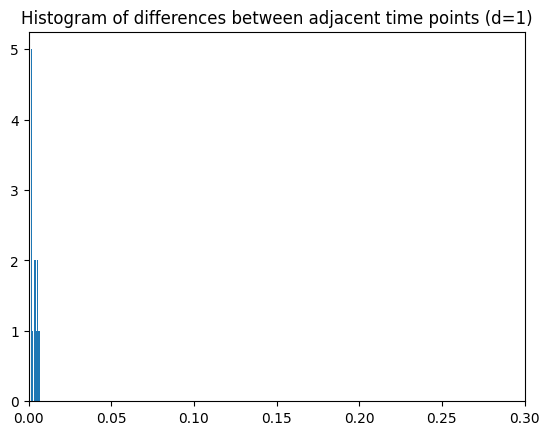

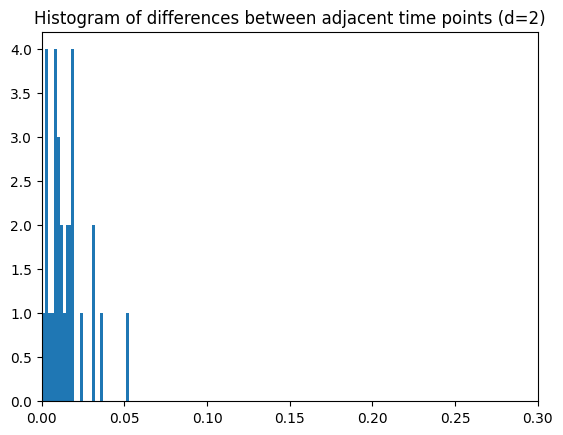

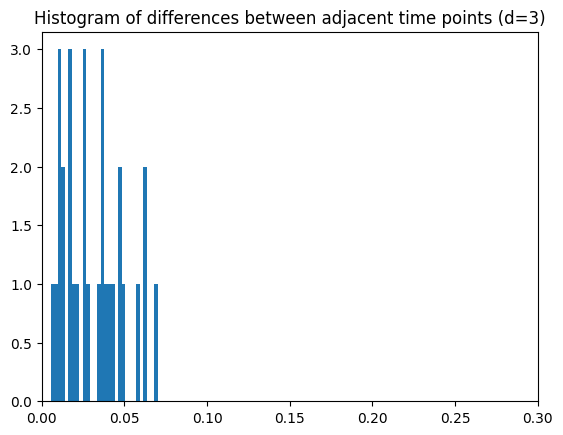

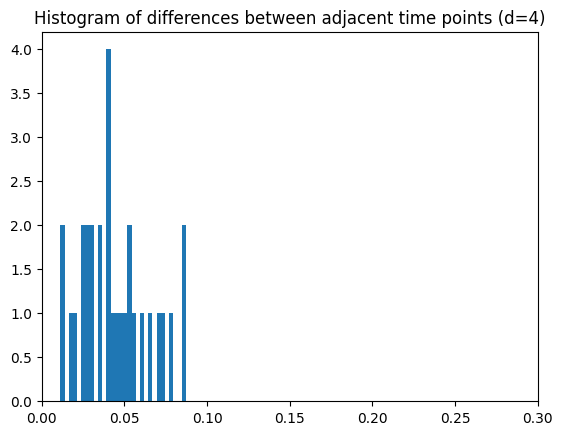

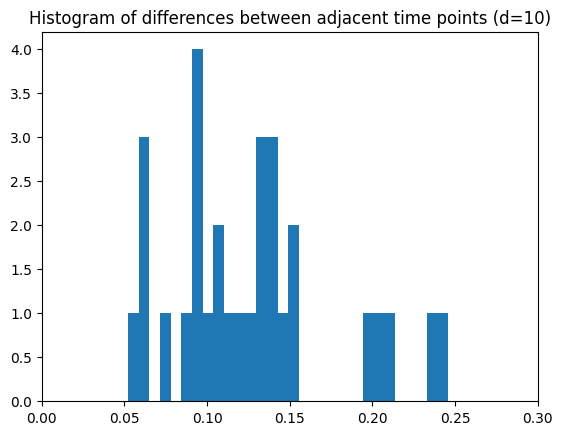

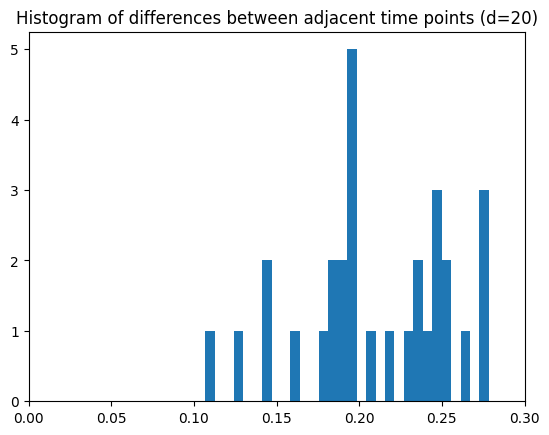

In [110]:
print(df_outcome.shape)
# u @ np.diag(s) @ vh = (u * s) @ vh



for d in [1, 2, 3, 4, 10, 20]:

    u, s, vh = np.linalg.svd(df_outcome, full_matrices=False)
    vh = vh[:d,:]

    diff_list = []
    for t in range(T-1):
        obs_curr = vh[:,t]
        obs_next = vh[:,t+1]
        diff = obs_next - obs_curr

        
        diff_list.append(np.sqrt(np.linalg.norm(vh[:,t] - vh[:,t+1])**2 / d))

    plt.hist(diff_list, bins=30)
    plt.xlim(0,0.3)
    plt.title(f"Histogram of differences between adjacent time points (d={d})")
    plt.show()

In [107]:
d = 1
df = df_outcome.T # T by N
M = Matrix(df, T0 = T0, target_name = "California")
M.denoise(num_sv = d)

syc = SyntheticControl()
syc.fit(M.pre_donor, M.pre_target, method="ridge", lmbda=0.1)

sc_pred = syc.predict(M.donor)


d = 2
df = df_outcome.T # T by N
M = Matrix(df, T0 = T0, target_name = "California")
M.denoise(num_sv = d)

syc = SyntheticControl()
syc.fit(M.pre_donor, M.pre_target, method="ridge", lmbda=0.1)

sc_pred2 = syc.predict(M.donor)


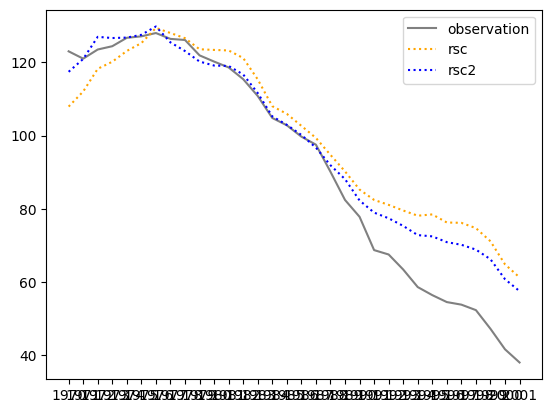

In [109]:
plt.plot(df["California"], color="grey", label="observation")
# plt.plot(Y_sig[0,:], color="red", label="true signal")

# plt.plot(target_pred_post, linestyle=":",color="green", label="TASC")
plt.plot(sc_pred, linestyle=":",color="orange", label="rsc")
plt.plot(sc_pred2, linestyle=":",color="blue", label="rsc2")

# plt.plot(Y_target, color="grey")
# plt.plot(Y_sig[:,0], color="red", label="target")
plt.legend()
plt.show()
